In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [28]:
df_index=pd.read_csv("economic_index.csv")

In [29]:
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [30]:
# drop unnecessary columns
df_index.drop(columns=["Unnamed: 0","year","month"])

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256
5,2.50,5.6,1254
6,2.50,5.5,1234
7,2.25,5.5,1195
8,2.25,5.5,1159
9,2.25,5.6,1167


In [31]:
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [32]:
## check null values

df_index.isnull().sum()

Unnamed: 0           0
year                 0
month                0
interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

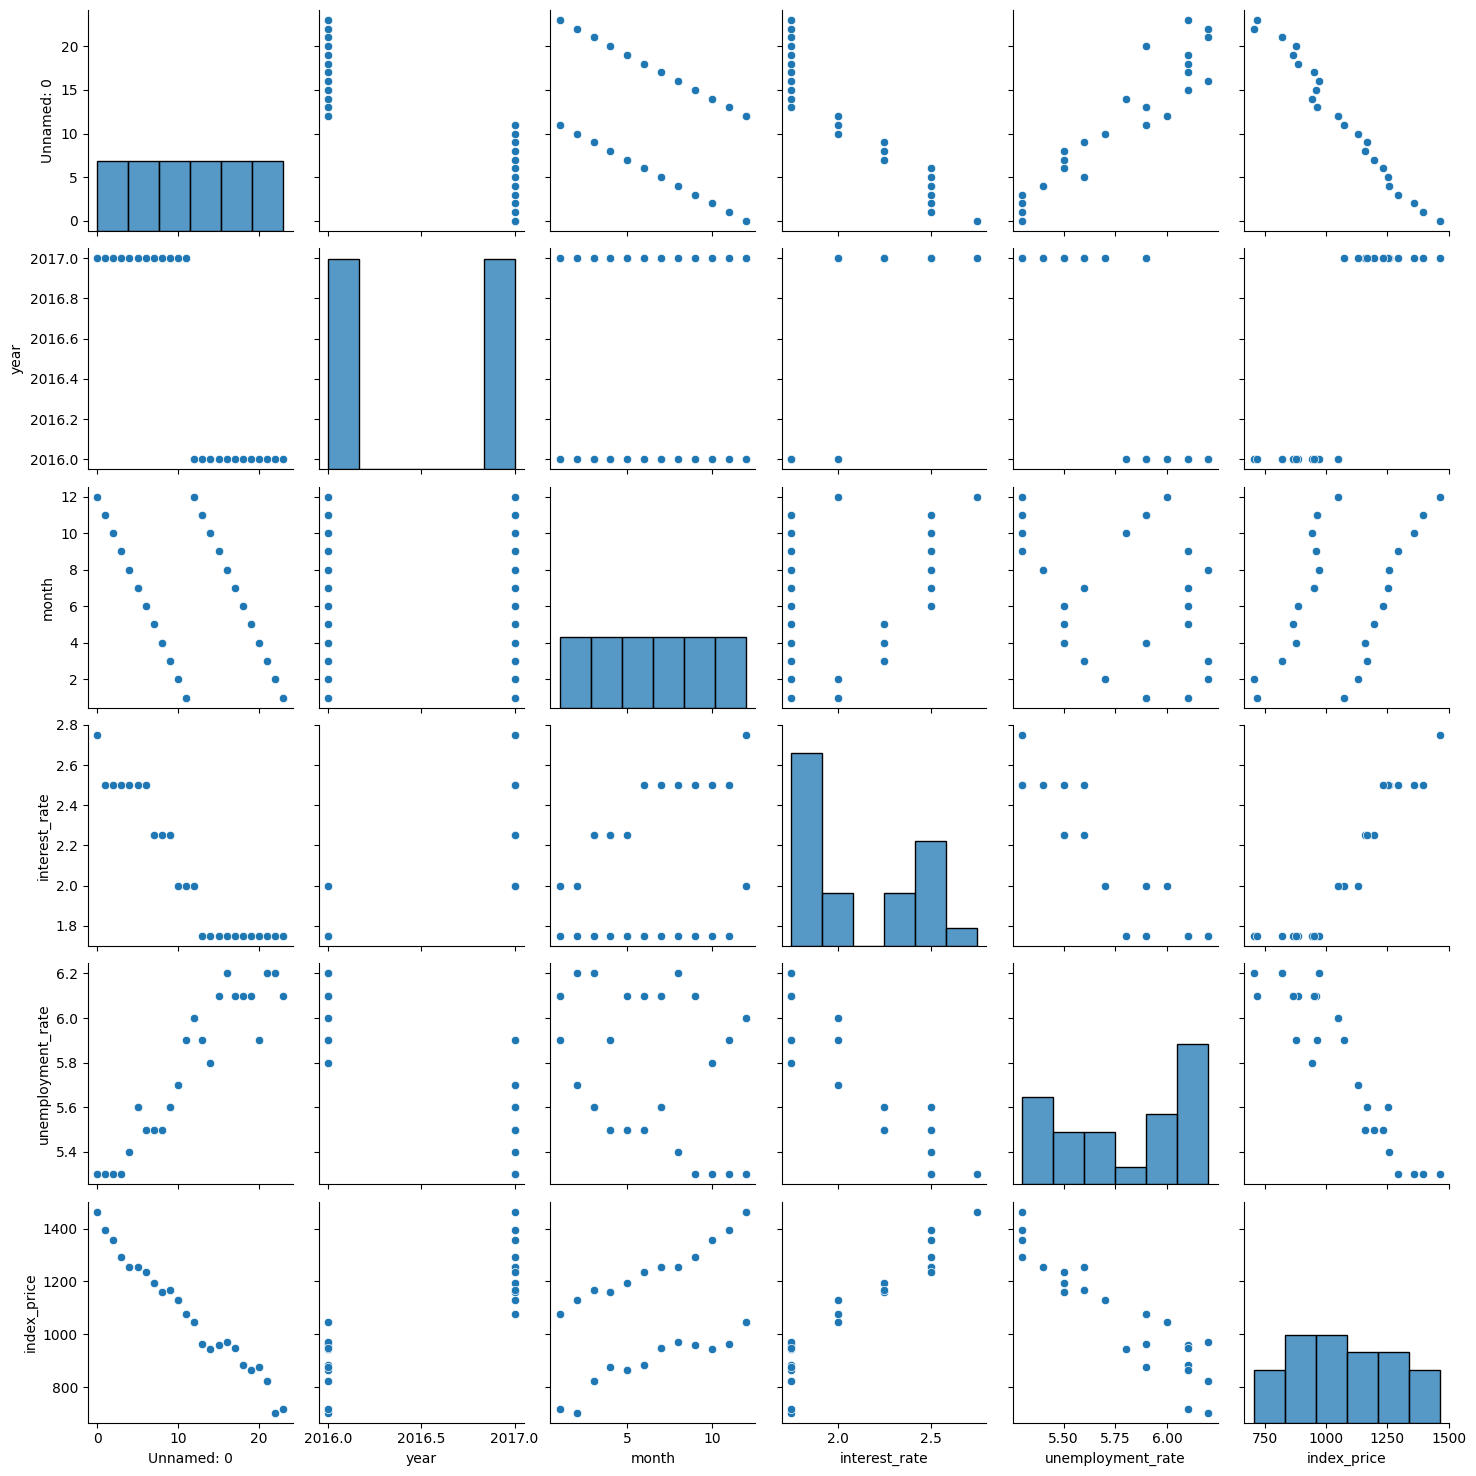

In [33]:
## visulization 
import seaborn as sns
sns.pairplot(df_index)


In [34]:
df_index.corr()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
Unnamed: 0,1.000000,-8.667781e-01,-4.986939e-01,-0.934555,0.935300,-0.988246
year,-0.866778,1.000000e+00,7.884865e-14,0.882851,-0.877000,0.863232
month,-0.498694,7.884865e-14,1.000000e+00,0.339526,-0.351189,0.481287
interest_rate,-0.934555,8.828507e-01,3.395257e-01,1.000000,-0.925814,0.935793
unemployment_rate,0.935300,-8.769997e-01,-3.511891e-01,-0.925814,1.000000,-0.922338
index_price,-0.988246,8.632321e-01,4.812873e-01,0.935793,-0.922338,1.000000


Text(0, 0.5, 'unemployment rate ')

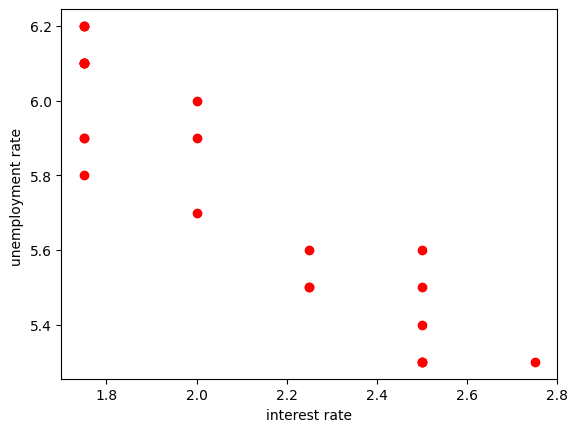

In [35]:
plt.scatter(df_index['interest_rate'],df_index['unemployment_rate'],color='r')
plt.xlabel("interest rate" )
plt.ylabel("unemployment rate ")

In [36]:
## get independent and dependent feature 

x=df_index.iloc[:,:-1]
y= df_index.iloc[:,-1]


In [37]:
x.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate
0,0,2017,12,2.75,5.3
1,1,2017,11,2.50,5.3
2,2,2017,10,2.50,5.3
3,3,2017,9,2.50,5.3
4,4,2017,8,2.50,5.4


In [38]:
## Train test split 
from sklearn.model_selection import train_test_split
x_train,x_test, y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)


In [39]:
import seaborn as sns


<Axes: xlabel='interest_rate', ylabel='index_price'>

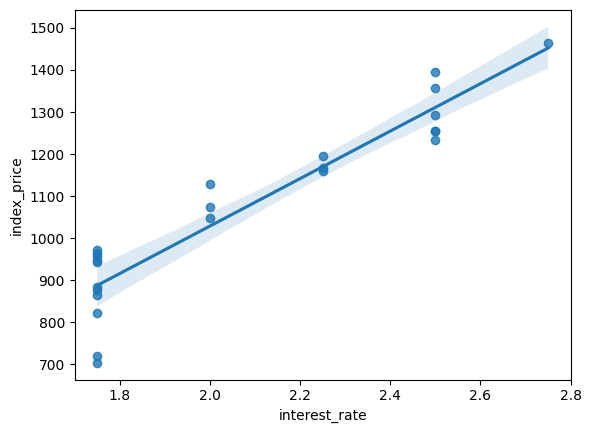

In [40]:
sns.regplot(x=df_index['interest_rate'], y=df_index['index_price'])

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

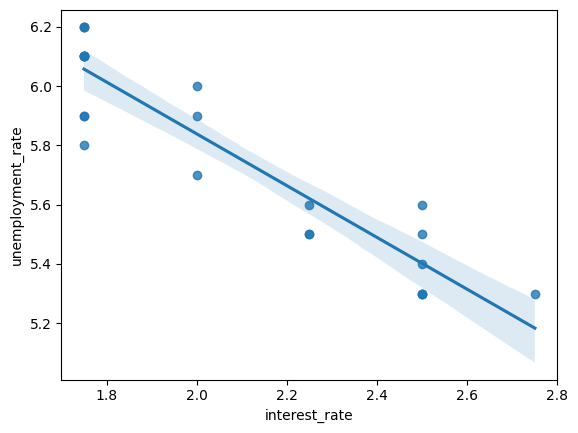

In [41]:
sns.regplot(x=df_index['interest_rate'], y=df_index['unemployment_rate'])

<Axes: xlabel='index_price', ylabel='unemployment_rate'>

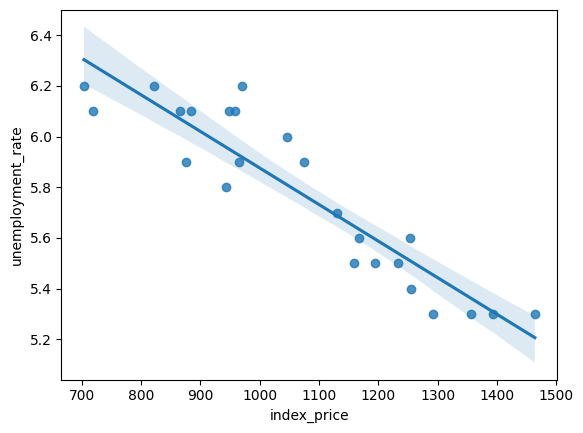

In [42]:
sns.regplot(x=df_index['index_price'], y=df_index['unemployment_rate'])

In [43]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()


In [44]:
regression.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[-29.52, 2.68, -2.63, 11.56, 13.39]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Unnamed: 0','year','month','interest_rate','unemployment_rate']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-4081
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4


In [45]:
regression.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[-29.52, 2.68, -2.63, 11.56, 13.39]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Unnamed: 0','year','month','interest_rate','unemployment_rate']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-4081
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4


In [46]:
from sklearn.model_selection import cross_val_score
validation_score=cross_val_score(regression,x_train,y_train,scoring='neg_mean_squared_error',cv=3)

In [47]:
np.mean(validation_score)

np.float64(-1556.413287290545)

In [48]:
## prediction
y_pred=regression.predict(x_test)

In [49]:
y_pred

array([1175.57032186,  929.78943375, 1393.85484386,  874.65503953,
       1097.34158614, 1150.01092165])

In [50]:
## performance metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

1294.7221344877319
29.43361153262549
35.982247490779834


In [52]:
n = len(y_test)
p = x_test.shape[1]

if n - p - 1 == 0:
    print("Adjusted R² cannot be calculated because n - p - 1 = 0")
else:
    adj_r2 = 1 - (1-score)*(n-1)/(n-p-1)
    print("Adjusted R²:", adj_r2)

Adjusted R² cannot be calculated because n - p - 1 = 0


print(len(y_test))
print(x_test.shape)

In [53]:
print("len(y_test):", len(y_test))
print("x_test shape:", x_test.shape)

n = len(y_test)
p = x_test.shape[1]

print("n =", n)
print("p =", p)
print("n - p - 1 =", n - p - 1)

len(y_test): 6
x_test shape: (6, 5)
n = 6
p = 5
n - p - 1 = 0


In [55]:
n = len(y_test)
p = x_test.shape[1]

if n > p + 1:
    adj_r2 = 1 - (1-score)*(n-1)/(n-p-1)
    print("Adjusted R²:", adj_r2)
else:
    print("Adjusted R² cannot be calculated because test set is too small.")

Adjusted R² cannot be calculated because test set is too small.


In [56]:
df_index.shape
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [57]:
df_index.shape
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [58]:
## assumption
from sklearn.metrics import r2_score 
score=r2_score(y_test,y_pred) 
print(score) ## display adjusted r square
print(1 - (1-score)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1))

0.96154062218089


ZeroDivisionError: float division by zero

In [59]:
print(df_index.shape)

(24, 6)


In [60]:
from sklearn.metrics import r2_score

score = r2_score(y_test, y_pred)
print("R² Score:", score)

R² Score: 0.96154062218089


In [61]:
X = df_index[['interest_rate', 'unemployment_rate']]

In [62]:
from sklearn.metrics import r2_score

score = r2_score(y_test, y_pred)
print("R² Score:", score)

R² Score: 0.96154062218089


## assumption 


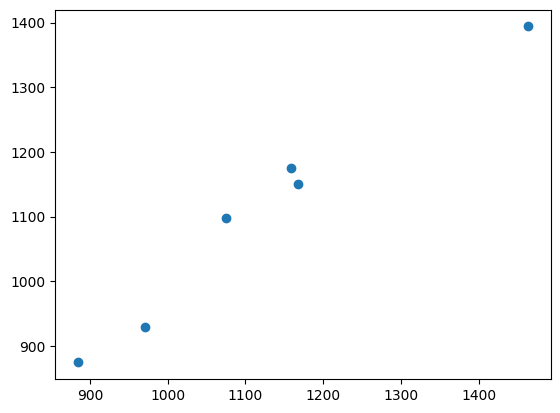

In [63]:
plt.scatter(y_test,y_pred)

In [64]:
residuals=y_test-y_pred
print(residuals)

8    -16.570322
16    41.210566
0     70.145156
18     9.344960
11   -22.341586
9     16.989078
Name: index_price, dtype: float64


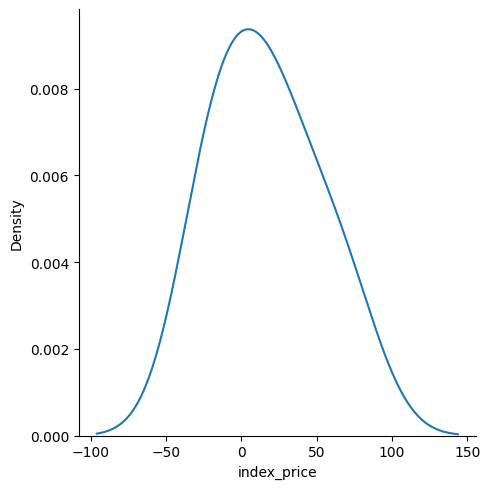

In [66]:
## plot this residuals
sns.displot(residuals,kind='kde')

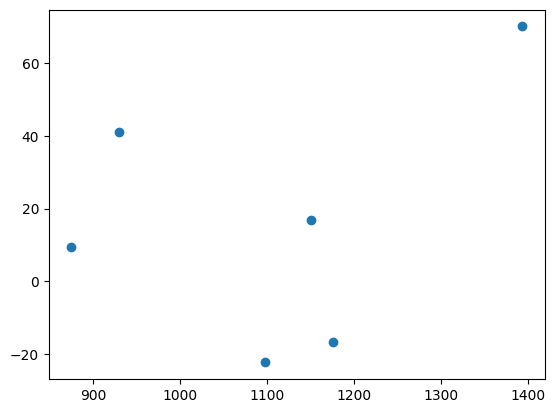

In [67]:
plt.scatter(y_pred,residuals)

In [70]:
## ols linear regression 
import statsmodels.api as sm
model= sm.OLS(y_train,x_train).fit()

In [71]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            index_price   R-squared:                       0.979
Model:                            OLS   Adj. R-squared:                  0.972
Method:                 Least Squares   F-statistic:                     150.7
Date:                Mon, 15 Jun 2026   Prob (F-statistic):           9.46e-11
Time:                        12:04:53   Log-Likelihood:                -87.130
No. Observations:                  18   AIC:                             184.3
Df Residuals:                      13   BIC:                             188.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Unnamed: 0          -29.6923      5.836     -5.087      0.000     -42.301     -17.083
year                  0.6568      0.265      2.483      0.027       0.085       1.228
month                -2.7944      4.109     -0.680      0.508     -11.672       6.083
interest_rate        11.5563     82.384      0.140      0.891    -166.423     189.536
unemployment_rate    13.3853     89.479      0.150      0.883    -179.922     206.692
==============================================================================
Omnibus:                        0.065   Durbin-Watson:                   1.967
Prob(Omnibus):                  0.968   Jarque-Bera (JB):                0.185
Skew:                          -0.116   Prob(JB):                        0.911
Kurtosis:                       2.560   Cond. No.                     2.17e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.17e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""